In [1]:
import numpy as np 
import pandas as pd 

In [2]:
data = pd.read_csv("dataset/Churn_Modelling.csv")

In [3]:
data.head(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [5]:
data.shape

(10000, 14)

### we can remove the RowNumber, CustomerID and Surname

In [6]:
data.drop(columns=['RowNumber','CustomerId','Surname'], inplace=True)

In [7]:
data.shape

(10000, 11)

As we are more focused on learning simple multi-layer neural network so we can do some basic
of Data alteration and jump directly on building NN

In [8]:
# now we should do the Data Encoding for columns = Gender, Geography

data['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [9]:
data['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [10]:

data = pd.get_dummies(data,columns=['Geography','Gender'],drop_first=True,dtype=int)

In [11]:
# now lets make the x and y data

x = data.drop(columns=["Exited"])
y = data['Exited']

from sklearn.model_selection import train_test_split

xtrain,xtest, ytrain, ytest = train_test_split(x,y, random_state=42)

In [22]:
# now lets to data normalizaiton

from sklearn.preprocessing import StandardScaler

ss = StandardScaler()

xtn = ss.fit_transform(xtrain)
xtst = ss.transform(xtest)

In [23]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential 
from tensorflow.keras.layers import Dense

In [24]:
model = Sequential()

model.add(Dense(11,activation='sigmoid',input_dim=11))
model.add(Dense(5,activation='sigmoid'))
model.add(Dense(1,activation='sigmoid'))

/home/anup/Documents/ml_pract/neural_network/neural-network/venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 198 (792.00 B)

 Trainable params: 198 (792.00 B)

 Non-trainable params: 0 (0.00 B)

In [26]:
model.compile(optimizer='Adam',loss='binary_crossentropy',metrics=['accuracy'])

In [27]:
history = model.fit(xtn,ytrain,batch_size=50,epochs=10,verbose=1,validation_split=0.2)


Epoch 1/10


120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7945 - loss: 0.5118 - val_accuracy: 0.7953 - val_loss: 0.5010
Epoch 2/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 902us/step - accuracy: 0.7945 - loss: 0.4969 - val_accuracy: 0.7953 - val_loss: 0.4902
Epoch 3/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7945 - loss: 0.4862 - val_accuracy: 0.7953 - val_loss: 0.4779
Epoch 4/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7945 - loss: 0.4746 - val_accuracy: 0.7953 - val_loss: 0.4657
Epoch 5/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 932us/step - accuracy: 0.7945 - loss: 0.4629 - val_accuracy: 0.7953 - val_loss: 0.4538
Epoch 6/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 991us/step - accuracy: 0.7945 - loss: 0.4523 - val_accuracy: 0.7953 - val_loss: 0.4439
Epoch 7/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7945 - loss: 0.4439 - val_accuracy: 0.7953 - val_loss: 0.4371
Epoch 8/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7945 - loss: 0.4381 - val_accuracy: 0.7953 

In [28]:
y_pred = model.predict(xtst)


79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 672us/step


In [29]:
y_pred

array([[0.17942826],
       [0.08807847],
       [0.3132492 ],
       ...,
       [0.05760346],
       [0.23708342],
       [0.09980909]], shape=(2500, 1), dtype=float32)

In [30]:
y_pred = y_pred.argmax(axis=-1)
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(2500,))

In [31]:
from sklearn.metrics import accuracy_score
accuracy_score(ytest,y_pred)

0.8012

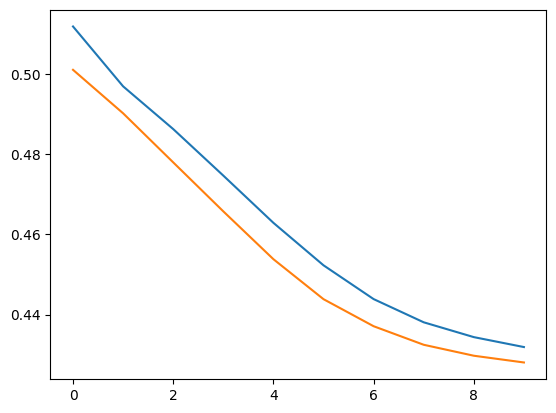

In [32]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])